In [6]:
using NPZ
using Glob
using Statistics
using Printf
using Dates

function average_data(L, T, dt, p, d, time_slice)

   # Root directory
    base_root = "/Users/dirac/Projects-Data/z3-data"

    # Input folder (fixed, existing)
    data_folder = joinpath(base_root, "z3-haar-data-26Dec2025")

    # Output folder (mean results)
    save_folder = joinpath(base_root, "z3-haar-data-26Dec2025-mean")
    mkpath(save_folder)

    # -----------------------
    # Correct file name pattern
    # Example:
    #   L8,T80.0,dt1.0,p0.0,dirQ,s6_hc.npy
    # -----------------------
    pattern = @sprintf("L%d,T%.1f,dt%.1f,p%.1f,dir%c,s*_hc.npy",
                       L, T, dt, p, d)

    # Find matching files inside the data folder
    shot_files = Glob.glob(pattern, data_folder)

    if isempty(shot_files)
        println("No matching files found in $data_folder")
        return
    end

    println("Found $(length(shot_files)) matching shots.")

    # Load every shot (each file is a vector)
    S_list = [npzread(f) for f in shot_files]

    # Convert list of vectors → matrix (shots × time)
    S_mat = reduce(vcat, [S' for S in S_list])

    # Compute mean and variance across shots
    S_mean = [mean(S_mat[:, i]) for i in 1:time_slice]
    S_var  = [var(S_mat[:, i])  for i in 1:time_slice]

    # Save results
    mean_file = @sprintf("Emean_L%d,T%.1f,dt%.1f,p%.1f_hc.npy", L, T, dt, p)
    var_file  = @sprintf("Evar_L%d,T%.1f,dt%.1f,p%.1f_hc.npy",  L, T, dt, p)

    npzwrite(joinpath(save_folder, mean_file), S_mean)
    npzwrite(joinpath(save_folder, var_file),  S_var)

    println("Saved results to $save_folder")
end

average_data (generic function with 1 method)

In [13]:
file = npzread("/Users/uditvarma/Project_Data/z3-haar_2025-12-08_mean/Emean_L8,T80.0,dt1.0,p0.0_hc.npy")

80-element Vector{Float64}:
 -1.9984014443253304e-17
  1.262292432127888
  2.407181934950096
  3.2236410820985895
  3.642412329274977
  3.8065093335918836
  3.86620404124176
  3.884763052507316
  3.891973391725892
  3.892946487813995
  ⋮
  3.89536136478127
  3.8954078350385375
  3.894357654065216
  3.894193894130835
  3.8946663210726724
  3.894337053850629
  3.894829721196814
  3.8949522118984867
  3.8946461484406023

In [14]:
using Plots

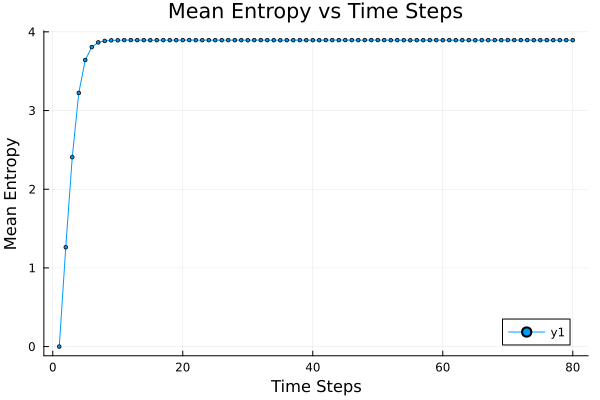

In [17]:
plot(file, xlabel="Time Steps", ylabel="Mean Entropy", title="Mean Entropy vs Time Steps", marker=:circle, markersize=2)

In [4]:
0.0:1.0:21

0.0:1.0:21.0

In [7]:
# --------------------------
# Example single run / sweep
# --------------------------
for L in [6, 8, 10]
    T = 10.0 * L
    for p in range(0.0, 1.0, length=21)
        for d in ["Q"]
            dt = 1.0
            average_data(L, T, dt, p, d, 10 * L)
        end
    end
end

Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean
Found 5000 matching shots.
Saved resu

In [8]:
using Glob
using Printf

# Mean data root
mean_root = "/Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean"

# Find all mean + variance files
files = Glob.glob("E*_L*,T*,dt*,p*_hc.npy", mean_root)

if isempty(files)
    println("No mean/variance files found.")
    return
end

for f in files
    fname = basename(f)

    # Extract L from filename
    # Example: Emean_L6,T60.0,dt1.0,p0.0_hc.npy
    m = match(r"L(\d+),", fname)
    if m === nothing
        @warn "Could not parse L from $fname"
        continue
    end

    L = m.captures[1]

    # Create folder for this L
    L_folder = joinpath(mean_root, "L$L")
    mkpath(L_folder)

    # Move file
    mv(f, joinpath(L_folder, fname); force=true)
end

println("Files organized by L successfully.")

Files organized by L successfully.


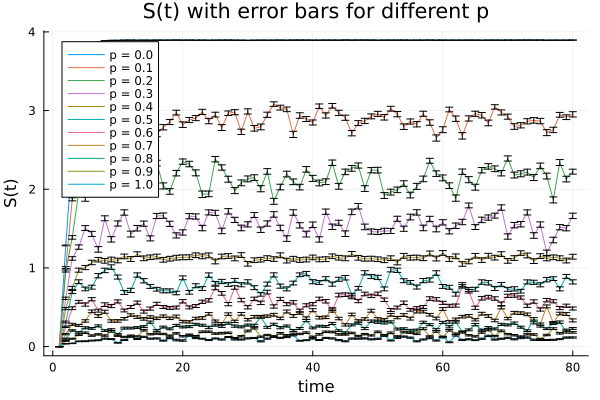

In [ ]:
using NPZ
using Glob
using Printf
using Plots       # uses GR backend by default

function plot_all_p(L, T, dt)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Search for all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    mean_files = Glob.glob(pattern, folder)

    if isempty(mean_files)
        println("No files found in $folder")
        return
    end

    # Arrays for sorting
    p_values = Float64[]
    mean_list = Vector{Vector{Float64}}()
    var_list  = Vector{Vector{Float64}}()

    # Load all mean + var files
    for mf in mean_files
        # Extract p from "p0.3_hc.npy"
        fname = basename(mf)
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        push!(p_values, p)
        push!(mean_list, npzread(mf))

        var_file = replace(mf, "Emean" => "Evar")
        push!(var_list, npzread(var_file))
    end

    # Sort everything by p
    perm = sortperm(p_values)
    p_values = p_values[perm]
    mean_list = mean_list[perm]
    var_list = var_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # ------------------------------------------
    # Plot all curves with error bars
    # ------------------------------------------
    plt = plot(title="S(t) with error bars for different p",
               xlabel="time", ylabel="S")

    for i in 1:length(p_values)
        errors = sqrt.(var_list[i])
        plot!(t, mean_list[i], yerr=errors/sqrt(1000),  # assuming 100 shots
              label = @sprintf("p = %.1f", p_values[i]))
    end

    display(plt)
end


# CALL THE FUNCTION
plot_all_p(8, 80.0, 1.0)


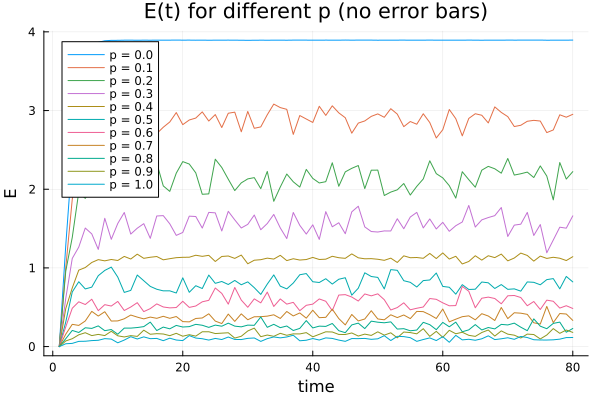

In [26]:
using NPZ
using Glob
using Printf
using Dates
using Plots

function plot_all_p_noerr(L, T, dt)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Locate all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    mean_files = Glob.glob(pattern, folder)

    if isempty(mean_files)
        println("No files found in $folder")
        return
    end

    p_values = Float64[]
    mean_list = Vector{Vector{Float64}}()

    # Read mean files
    for mf in mean_files
        fname = basename(mf)
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        push!(p_values, p)
        push!(mean_list, npzread(mf))
    end

    # Sort by p
    perm = sortperm(p_values)
    p_values = p_values[perm]
    mean_list = mean_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # Plot all curves (no error bars)
    plt = plot(title="E(t) for different p (no error bars)",
               xlabel="time", ylabel="E")

    for i in 1:length(p_values)
        plot!(t, mean_list[i], label=@sprintf("p = %.1f", p_values[i]))
    end

    display(plt)
end

# Run it
plot_all_p_noerr(8, 80.0, 1.0)


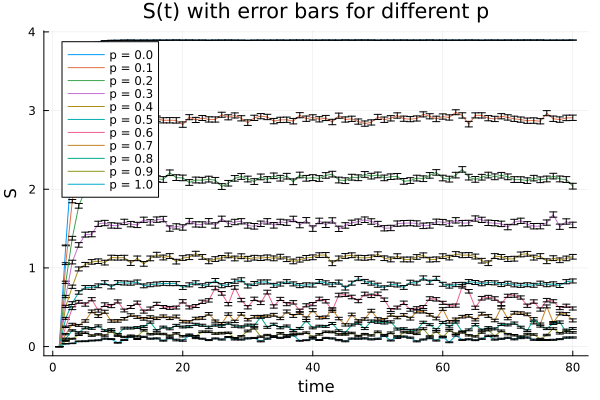

In [32]:
using NPZ
using Glob
using Printf
using Plots       # uses GR backend by default

function plot_all_p(L, T, dt)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Search for all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    mean_files = Glob.glob(pattern, folder)

    if isempty(mean_files)
        println("No files found in $folder")
        return
    end

    # Arrays for sorting
    p_values = Float64[]
    mean_list = Vector{Vector{Float64}}()
    var_list  = Vector{Vector{Float64}}()

    # Load all mean + var files
    for mf in mean_files
        # Extract p from "p0.3_hc.npy"
        fname = basename(mf)
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        push!(p_values, p)
        push!(mean_list, npzread(mf))

        var_file = replace(mf, "Emean" => "Evar")
        push!(var_list, npzread(var_file))
    end

    # Sort everything by p
    perm = sortperm(p_values)
    p_values = p_values[perm]
    mean_list = mean_list[perm]
    var_list = var_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # ------------------------------------------
    # Plot all curves with error bars
    # ------------------------------------------
    plt = plot(title="S(t) with error bars for different p",
               xlabel="time", ylabel="S")

    for i in 1:length(p_values)
        errors = sqrt.(var_list[i])
        plot!(t, mean_list[i], yerr=errors/sqrt(1000),  # assuming 100 shots
              label = @sprintf("p = %.1f", p_values[i]))
    end

    display(plt)
end


# CALL THE FUNCTION
plot_all_p(8, 80.0, 1.0)

plot_selected_p (generic function with 1 method)

In [36]:
using NPZ
using Glob
using Printf
using Plots

function plot_selected_p(L, T, dt, p_list_to_plot)

    base = "/Users/uditvarma/Project_Data"
    date_str = Dates.format(Dates.today(), "yyyy-mm-dd")
    folder = joinpath(base, "z3-haar_" * date_str * "_mean")

    # Search for all mean files
    pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
    all_mean_files = Glob.glob(pattern, folder)

    if isempty(all_mean_files)
        println("No files found in $folder")
        return
    end

    # Storage
    selected_p = Float64[]
    mean_list = Vector{Vector{Float64}}()
    var_list  = Vector{Vector{Float64}}()

    for mf in all_mean_files
        fname = basename(mf)

        # Extract p value
        p_str = split(split(fname, "p")[2], "_")[1]
        p = parse(Float64, p_str)

        # Skip p values NOT requested
        if !(p in p_list_to_plot)
            continue
        end

        push!(selected_p, p)
        push!(mean_list, npzread(mf))

        var_file = replace(mf, "Emean" => "Evar")
        push!(var_list, npzread(var_file))
    end

    if isempty(selected_p)
        println("No requested p values found.")
        return
    end

    # Sort by p
    perm = sortperm(selected_p)
    selected_p = selected_p[perm]
    mean_list  = mean_list[perm]
    var_list   = var_list[perm]

    # Time axis
    t = 1:length(mean_list[1])

    # Plot
    plt = plot(title="S(t) vs t",
               xlabel="Time", ylabel="S")

    for i in 1:length(selected_p)
        errors = sqrt.(var_list[i]) ./ sqrt(1000)
        plot!(t, mean_list[i], yerr=errors,
              label=@sprintf("p = %.2f", selected_p[i]))
    end

    display(plt)
end

plot_selected_p (generic function with 1 method)

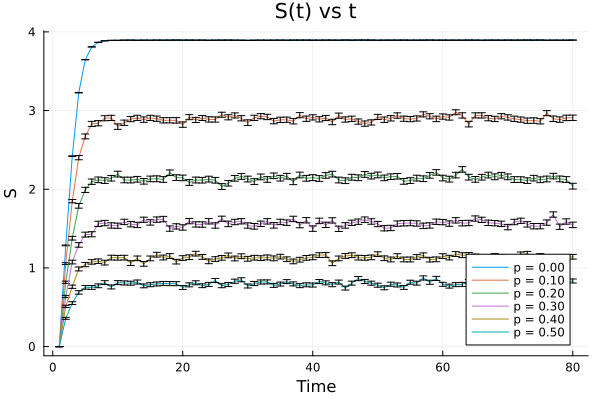

In [37]:
plot_selected_p(8, 80.0, 1.0, [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])

In [2]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
63×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     6     0.0     5000
   2 │     6     0.05    5000
   3 │     6     0.1     5000
   4 │     6     0.15    5000
   5 │     6     0.2     5000
   6 │     6     0.25    5000
   7 │     6     0.3     5000
   8 │     6     0.35    5000
   9 │     6     0.4     5000
  10 │     6     0.45    5000
  11 │     6     0.5     5000
  12 │     6     0.55    5000
  13 │     6     0.6     5000
  14 │     6     0.65    5000
  15 │     6     0.7     5000
  16 │     6     0.75    5000
  17 │     6     0.8     5000
  18 │     6     0.85    5000
  19 │     6     0.9     5000
  20 │     6     0.95    5000
  21 │     6     1.0     5000
  22 │     8     0.0     5000
  23 │     8     0.05    5000
  24 │     8     0.1     5000
  25 │     8     0.15    4980
  26 │     8     0.2     5000
  27 │     8     0.25    5000
  28 │     8     0.3     5000

In [1]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
63×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     6     0.0     5000
   2 │     6     0.05    5000
   3 │     6     0.1     5000
   4 │     6     0.15    5000
   5 │     6     0.2     5000
   6 │     6     0.25    5000
   7 │     6     0.3     5000
   8 │     6     0.35    5000
   9 │     6     0.4     5000
  10 │     6     0.45    5000
  11 │     6     0.5     5000
  12 │     6     0.55    5000
  13 │     6     0.6     5000
  14 │     6     0.65    5000
  15 │     6     0.7     5000
  16 │     6     0.75    5000
  17 │     6     0.8     4990
  18 │     6     0.85    5000
  19 │     6     0.9     5000
  20 │     6     0.95    5000
  21 │     6     1.0     5000
  22 │     8     0.0     5000
  23 │     8     0.05    5000
  24 │     8     0.1     5000
  25 │     8     0.15    5000
  26 │     8     0.2     5000
  27 │     8     0.25    5000
  28 │     8     0.3     5000

In [11]:
using NPZ
using Glob
using Printf
using Plots

function plot_by_L_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-haar-data-26Dec2025-mean")

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "L$L")

        pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
        mean_files = Glob.glob(pattern, folder)

        if isempty(mean_files)
            @warn "No files found for L=$L"
            continue
        end

        p_values  = Float64[]
        mean_list = Vector{Vector{Float64}}()
        var_list  = Vector{Vector{Float64}}()

        for mf in mean_files
            fname = basename(mf)
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            push!(p_values, p)
            push!(mean_list, npzread(mf))

            var_file = replace(mf, "Emean" => "Evar")
            push!(var_list, npzread(var_file))
        end

        # Sort by p
        perm = sortperm(p_values)
        p_values  = p_values[perm]
        mean_list = mean_list[perm]
        var_list  = var_list[perm]

        t = 1:length(mean_list[1])

        plt = plot(
            title  = @sprintf("S(t) for L = %d", L),
            xlabel = "time",
            ylabel = "S",
            legend = :right
        )

        for i in eachindex(p_values)
            errors = sqrt.(var_list[i])
            plot!(
                t,
                mean_list[i],
                yerr = errors ./ sqrt(5000),
                label = @sprintf("p = %.2f", p_values[i])
            )
        end

        # -----------------------
        # SAVE AS SVG
        # -----------------------
        out_svg = joinpath(folder, @sprintf("S_vs_t_L%d.svg", L))
        savefig(plt, out_svg)

        println("Saved → $out_svg")
    end
end

# ----------------------
# CALL
# ----------------------
plot_by_L_svg([6, 8, 10], 1.0)


Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L6/S_vs_t_L6.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L8/S_vs_t_L8.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L10/S_vs_t_L10.svg


In [40]:
using NPZ
using Glob
using Printf
using Plots

function plot_final_variance_vs_p_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-haar-data-26Dec2025-mean")

    plt = plot(
        xlabel = "p",
        ylabel = "δS(t)",
        title  = "Steady-state variance vs p",
        legend = :topright,
        marker = :circle
    )

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "L$L")

        pattern = @sprintf("Evar_L%d,T%.1f,dt%.1f,p*_hc.npy", L, T, dt)
        var_files = Glob.glob(pattern, folder)

        if isempty(var_files)
            @warn "No variance files found for L=$L"
            continue
        end

        p_values = Float64[]
        final_vars = Float64[]

        for vf in var_files
            fname = basename(vf)

            # extract p from filename
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            var_data = npzread(vf)
            final_var = var_data[end]   # FINAL TIME VALUE

            push!(p_values, p)
            push!(final_vars, final_var)
        end

        # sort by p
        perm = sortperm(p_values)
        p_values   = p_values[perm]
        final_vars = final_vars[perm]

        plot!(
            p_values,
            final_vars,
            label = @sprintf("L = %d", L)
        )
    end

    # -----------------------
    # SAVE AS SVG
    # -----------------------
    out_svg = joinpath(mean_root, "final_variance_vs_p.svg")
    savefig(plt, out_svg)

    println("Saved → $out_svg")
end

# ----------------------
# CALL
# ----------------------
plot_final_variance_vs_p_svg([6, 8, 10], 1.0)


Saved → /Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/final_variance_vs_p.svg


In [12]:
npzread("/Users/dirac/Projects-Data/z3-data/z3-haar-data-26Dec2025-mean/L8/Emean_L8,T80.0,dt1.0,p1.0_hc.npy")

80-element Vector{Float64}:
 3.6415315207705074e-17
 0.040900373511640734
 0.05510347731805159
 0.0734323807387099
 0.084224322229018
 0.05406211386132771
 0.09283863172387151
 0.08826277903976977
 0.08548485956382391
 0.088564541275996
 0.07828718828234373
 0.0949872042023508
 0.09294522387652444
 ⋮
 0.08631777343676288
 0.09954668633263328
 0.09065140425807809
 0.10274122726200176
 0.10282802018011926
 0.09662265428260665
 0.0958155033064394
 0.10124594595652163
 0.09647232569666762
 0.09183558382496805
 0.09457815606317478
 0.10692030858965909

### Shannon entropy data

In [28]:
using NPZ
using Glob
using Statistics
using Printf
using Dates

function average_data(L, T, dt, p, d, time_slice)

   # Root directory
    base_root = "/Users/dirac/Projects-Data/z3-data"

    # Input folder (fixed, existing)
    data_folder = joinpath(base_root, "z3-shannon-data-26Dec2025")

    # Output folder (mean results)
    save_folder = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")
    mkpath(save_folder)

    # -----------------------
    # Correct file name pattern
    # Example:
    #   L8,T80.0,dt1.0,p0.0,dirQ,s6_hc.npy
    # -----------------------
    pattern = @sprintf("L%d,T%.1f,dt%.1f,p%.1f,dir%c,s*_se.npy",
                       L, T, dt, p, d)

    # Find matching files inside the data folder
    shot_files = Glob.glob(pattern, data_folder)

    if isempty(shot_files)
        println("No matching files found in $data_folder")
        return
    end

    println("Found $(length(shot_files)) matching shots.")

    # Load every shot (each file is a vector)
    S_list = [npzread(f) for f in shot_files]

    # Convert list of vectors → matrix (shots × time)
    S_mat = reduce(vcat, [S' for S in S_list])

    # Compute mean and variance across shots
    S_mean = [mean(S_mat[:, i]) for i in 1:time_slice]
    S_var  = [var(S_mat[:, i])  for i in 1:time_slice]

    # Save results
    mean_file = @sprintf("Emean_L%d,T%.1f,dt%.1f,p%.1f_se.npy", L, T, dt, p)
    var_file  = @sprintf("Evar_L%d,T%.1f,dt%.1f,p%.1f_se.npy",  L, T, dt, p)

    npzwrite(joinpath(save_folder, mean_file), S_mean)
    npzwrite(joinpath(save_folder, var_file),  S_var)

    println("Saved results to $save_folder")
end

average_data (generic function with 1 method)

In [29]:
# --------------------------
# Example single run / sweep
# --------------------------
for L in [6, 8, 10]
    T = 10.0 * L
    for p in [
    0.0, 0.05, 0.1, 0.15, 0.2,
    0.25, 0.3, 0.35, 0.4, 0.45,
    0.5, 0.55, 0.6, 0.65, 0.7,
    0.75, 0.8, 0.85, 0.9, 0.95, 1.0
]
        for d in ["Q"]
            dt = 1.0
            average_data(L, T, dt, p, d, 10 * L)
        end
    end
end

Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean
Found 5000

In [31]:
using Glob
using Printf

# Mean data root
mean_root = "/Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean"

# Find all mean + variance files
files = Glob.glob("E*_L*,T*,dt*,p*_se.npy", mean_root)

if isempty(files)
    println("No mean/variance files found.")
    return
end

for f in files
    fname = basename(f)

    # Extract L from filename
    # Example: Emean_L6,T60.0,dt1.0,p0.0_hc.npy
    m = match(r"L(\d+),", fname)
    if m === nothing
        @warn "Could not parse L from $fname"
        continue
    end

    L = m.captures[1]

    # Create folder for this L
    L_folder = joinpath(mean_root, "L$L")
    mkpath(L_folder)

    # Move file
    mv(f, joinpath(L_folder, fname); force=true)
end

println("Files organized by L successfully.")

Files organized by L successfully.


In [42]:
using NPZ
using Glob
using Printf
using Plots

function plot_by_L_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-shannon-data-26Dec2025-mean")

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "L$L")

        pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_se.npy", L, T, dt)
        mean_files = Glob.glob(pattern, folder)

        if isempty(mean_files)
            @warn "No files found for L=$L"
            continue
        end

        p_values  = Float64[]
        mean_list = Vector{Vector{Float64}}()
        var_list  = Vector{Vector{Float64}}()

        for mf in mean_files
            fname = basename(mf)
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            push!(p_values, p)
            push!(mean_list, npzread(mf))

            var_file = replace(mf, "Emean" => "Evar")
            push!(var_list, npzread(var_file))
        end

        # Sort by p
        perm = sortperm(p_values)
        p_values  = p_values[perm]
        mean_list = mean_list[perm]
        var_list  = var_list[perm]

        t = 1:length(mean_list[1])

        plt = plot(
            title  = @sprintf("S(t) for L = %d", L),
            xlabel = "time",
            ylabel = "S",
            legend = false
        )

        for i in eachindex(p_values)
            errors = sqrt.(var_list[i])
            plot!(
                t,
                mean_list[i],
                yerr = errors ./ sqrt(5000),
                label = @sprintf("p = %.2f", p_values[i])
            )
        end

        # -----------------------
        # SAVE AS SVG
        # -----------------------
        out_svg = joinpath(folder, @sprintf("S_vs_t_L%d.svg", L))
        savefig(plt, out_svg)

        println("Saved → $out_svg")
    end
end

# ----------------------
# CALL
# ----------------------
plot_by_L_svg([6, 8, 10], 1.0)

Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/L6/S_vs_t_L6.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/L8/S_vs_t_L8.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/L10/S_vs_t_L10.svg


In [35]:
using NPZ
using Glob
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# -------------------------------------------------
# Find all L folders
# -------------------------------------------------
L_folders = sort(Glob.glob("L*", mean_root))

for L_folder in L_folders
    Lname = basename(L_folder)

    # Extract L
    mL = match(r"L(\d+)", Lname)
    mL === nothing && continue
    L = parse(Int, mL.captures[1])

    println("\nProcessing L = $L")

    # -------------------------------------------------
    # Detect p values for this L
    # -------------------------------------------------
    mean_files = Glob.glob("Emean_L*,p*_se.npy", L_folder)

    p_vals = Float64[]
    for f in mean_files
        m = match(r"p([0-9]+\.[0-9]+)", basename(f))
        m !== nothing && push!(p_vals, parse(Float64, m.captures[1]))
    end
    p_vals = sort(unique(p_vals))

    np = length(p_vals)
    @assert np > 0 "No p values found for L=$L"

    # -------------------------------------------------
    # Allocate array: (p, mean, var)
    # -------------------------------------------------
    data = Array{Float64}(undef, np, 3)

    # -------------------------------------------------
    # Load final values
    # -------------------------------------------------
    for (ip, p) in enumerate(p_vals)

        mean_file = joinpath(
            L_folder,
            @sprintf("Emean_L%d,T%.1f,dt1.0,p%.2f_se.npy", L, 10.0*L, p)
        )
        var_file = joinpath(
            L_folder,
            @sprintf("Evar_L%d,T%.1f,dt1.0,p%.2f_se.npy", L, 10.0*L, p)
        )

        if !isfile(mean_file) || !isfile(var_file)
            @warn "Missing data for L=$L p=$p"
            data[ip, :] .= NaN
            continue
        end

        data[ip, 1] = p
        data[ip, 2] = npzread(mean_file)[end]  # final mean
        data[ip, 3] = npzread(var_file)[end]   # final variance
    end

    # -------------------------------------------------
    # Save single file per L
    # -------------------------------------------------
    out_file = joinpath(mean_root, @sprintf("E_final_L%d.npy", L))
    npzwrite(out_file, data)

    println("Saved → $out_file")
end


Processing L = 10
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L10.npy

Processing L = 6
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L6.npy

Processing L = 8
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L8.npy


┌ Warning: Missing data for L=10 p=0.0
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.1
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.2
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.3
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.4
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.5
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.6
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.7
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.8
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=0.9
└ @ Main In[35]:61
┌ Warning: Missing data for L=10 p=1.0
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.0
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.1
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.2
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.3
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.4
└ @ Main In[35]:61
┌ Warning: Missing data for L=6 p=0.5
└ @ Main In[35]:61
┌ Warning: Missing d

In [36]:
using NPZ
using Glob
using Printf

base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Find all L folders
L_folders = sort(Glob.glob("L*", mean_root))

for L_folder in L_folders
    Lname = basename(L_folder)

    # Extract L
    mL = match(r"L(\d+)", Lname)
    mL === nothing && continue
    L = parse(Int, mL.captures[1])

    println("\nProcessing L = $L")

    # -------------------------------------------------
    # Find all mean files for this L
    # -------------------------------------------------
    mean_files = sort(Glob.glob("Emean_L*,p*_se.npy", L_folder))
    nfiles = length(mean_files)

    @assert nfiles > 0 "No mean files found for L=$L"

    # -------------------------------------------------
    # Allocate array: (p, mean, var)
    # -------------------------------------------------
    data = Array{Float64}(undef, nfiles, 3)

    # -------------------------------------------------
    # Loop over files
    # -------------------------------------------------
    for (i, mf) in enumerate(mean_files)
        fname = basename(mf)

        # Extract p robustly
        mp = match(r"p([0-9]*\.?[0-9]+)", fname)
        mp === nothing && error("Could not parse p from $fname")
        p = parse(Float64, mp.captures[1])

        # Corresponding variance file
        vf = replace(mf, "Emean" => "Evar")
        @assert isfile(vf) "Missing variance file for $fname"

        # Load final values
        data[i, 1] = p
        data[i, 2] = npzread(mf)[end]
        data[i, 3] = npzread(vf)[end]
    end

    # -------------------------------------------------
    # Sort by p
    # -------------------------------------------------
    perm = sortperm(data[:, 1])
    data = data[perm, :]

    # -------------------------------------------------
    # Save single file per L
    # -------------------------------------------------
    out_file = joinpath(mean_root, @sprintf("E_final_L%d.npy", L))
    npzwrite(out_file, data)

    println("Saved → $out_file")
end



Processing L = 10
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L10.npy

Processing L = 6
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L6.npy

Processing L = 8
Saved → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/E_final_L8.npy


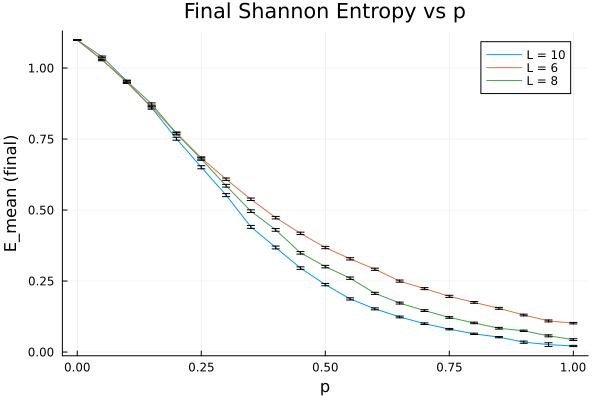

Saved plot → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/Emean_vs_p_all_L_with_errors.svg


In [37]:
using NPZ
using Glob
using Plots
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Number of shots (CHANGE if needed)
Nshots = 5000

# -------------------------------------------------
# Find all per-L summary files
# -------------------------------------------------
summary_files = sort(Glob.glob("E_final_L*.npy", mean_root))
@assert !isempty(summary_files) "No E_final_L*.npy files found"

# -------------------------------------------------
# Initialize plot
# -------------------------------------------------
plt = plot(
    xlabel = "p",
    ylabel = "E_mean (final)",
    title  = "Final Shannon Entropy vs p",
    legend = :best,
    lw = 2,
    marker = :circle
)

# -------------------------------------------------
# Plot each L with error bars
# -------------------------------------------------
for f in summary_files
    fname = basename(f)

    # Extract L
    m = match(r"L(\d+)", fname)
    m === nothing && continue
    L = parse(Int, m.captures[1])

    data = npzread(f)

    p     = data[:, 1]
    mean  = data[:, 2]
    var   = data[:, 3]

    # Error bars
    err = sqrt.(var ./ Nshots)   # ← remove "/ Nshots" if undesired

    plot!(
        plt,
        p,
        mean,
        yerr = err,
        label = "L = $L"
    )
end

# -------------------------------------------------
# Save SVG
# -------------------------------------------------
out_svg = joinpath(mean_root, "Emean_vs_p_all_L_with_errors.svg")
savefig(plt, out_svg)

display(plt)

println("Saved plot → $out_svg")


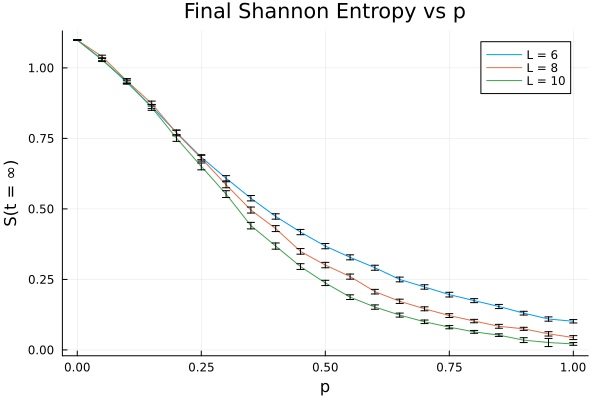

Saved plot → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/Emean_vs_p_all_L_with_errors.svg


In [44]:
using NPZ
using Glob
using Plots
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Number of shots
Nshots = 1000

# -------------------------------------------------
# Find summary files
# -------------------------------------------------
summary_files = Glob.glob("E_final_L*.npy", mean_root)
@assert !isempty(summary_files) "No E_final_L*.npy files found"

# -------------------------------------------------
# Sort by numeric L (smallest first)
# -------------------------------------------------
summary_files = sort(
    summary_files,
    by = f -> parse(Int, match(r"L(\d+)", basename(f)).captures[1])
)

# -------------------------------------------------
# Initialize plot
# -------------------------------------------------
plt = plot(
    xlabel = "p",
    ylabel = "S(t = ∞)",
    title  = "Final Shannon Entropy vs p",
    legend = :best,
    lw = 2,
    marker = :circle
)

# -------------------------------------------------
# Plot each L
# -------------------------------------------------
for f in summary_files
    L = parse(Int, match(r"L(\d+)", basename(f)).captures[1])

    data = npzread(f)

    p     = data[:, 1]
    mean  = data[:, 2]
    var   = data[:, 3]

    err = sqrt.(var ./ Nshots)

    plot!(
        plt,
        p,
        mean,
        yerr = err,
        label = "L = $L"
    )
end

# -------------------------------------------------
# Save SVG
# -------------------------------------------------
out_svg = joinpath(mean_root, "Emean_vs_p_all_L_with_errors.svg")
savefig(plt, out_svg)

display(plt)

println("Saved plot → $out_svg")


In [ ]:
xlims!(plt, 0.3, 0.7)


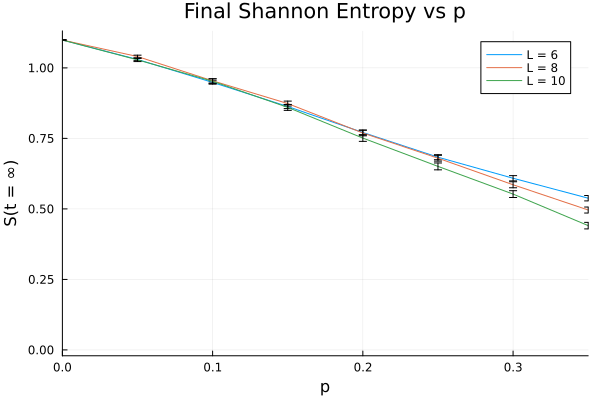

Saved plot → /Users/dirac/Projects-Data/z3-data/z3-shannon-data-26Dec2025-mean/Emean_vs_p_all_L_zoomed.svg


In [49]:
using NPZ
using Glob
using Plots
using Printf

# -------------------------------------------------
# Paths
# -------------------------------------------------
base_root = "/Users/dirac/Projects-Data/z3-data"
mean_root = joinpath(base_root, "z3-shannon-data-26Dec2025-mean")

# Number of shots
Nshots = 1000

# -------------------------------------------------
# Find summary files
# -------------------------------------------------
summary_files = Glob.glob("E_final_L*.npy", mean_root)
@assert !isempty(summary_files) "No E_final_L*.npy files found"

# -------------------------------------------------
# Sort by numeric L (smallest first)
# -------------------------------------------------
summary_files = sort(
    summary_files,
    by = f -> parse(Int, match(r"L(\d+)", basename(f)).captures[1])
)

# -------------------------------------------------
# Initialize plot
# -------------------------------------------------
plt = plot(
    xlabel = "p",
    ylabel = "S(t = ∞)",
    title  = "Final Shannon Entropy vs p",
    legend = :best,
    lw = 2,
    marker = :circle
)

# -------------------------------------------------
# Plot each L
# -------------------------------------------------
for f in summary_files
    L = parse(Int, match(r"L(\d+)", basename(f)).captures[1])

    data = npzread(f)

    p     = data[:, 1]
    mean  = data[:, 2]
    var   = data[:, 3]

    err = sqrt.(var ./ Nshots)

    plot!(
        plt,
        p,
        mean,
        yerr = err,
        label = "L = $L"
    )
end

# -------------------------------------------------
# Save SVG
# -------------------------------------------------
xlims!(plt, 0.0, 0.35)

out_svg = joinpath(mean_root, "Emean_vs_p_all_L_zoomed.svg")
savefig(plt, out_svg)

display(plt)

println("Saved plot → $out_svg")


### Optimized code

In [54]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_hc"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
22×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     8      0.0    4990
   2 │     8      0.1    5000
   3 │     8      0.2    4995
   4 │     8      0.3    5000
   5 │     8      0.4    4995
   6 │     8      0.5    4990
   7 │     8      0.6    5000
   8 │     8      0.7    5000
   9 │     8      0.8    5000
  10 │     8      0.9    5000
  11 │     8      1.0    5000
  12 │    12      0.0    5000
  13 │    12      0.1    5000
  14 │    12      0.2    5000
  15 │    12      0.3    4995
  16 │    12      0.4    5000
  17 │    12      0.5    5000
  18 │    12      0.6    5000
  19 │    12      0.7    5000
  20 │    12      0.8    5000
  21 │    12      0.9    5000
  22 │    12      1.0    5000


In [52]:
using DataFrames
using CSV

# Base directory
base_dir = "/Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026"

# Regex:
# Example filename:
# L6,T60.0,dt1.0,p0.0,dirQ,s8_hc.npy
pattern = r"L(\d+),.*?,p([0-9.]+),.*?,s(\d+)_se"

rows = DataFrame(
    L = Int[],
    p = Float64[],
    shot = Int[]
)

for (root, _, files) in walkdir(base_dir)
    for f in files
        m = match(pattern, f)
        if m !== nothing
            push!(rows, (
                L = parse(Int, m.captures[1]),
                p = parse(Float64, m.captures[2]),
                shot = parse(Int, m.captures[3])
            ))
        end
    end
end

# Group by (L, p) and count unique shots
ledger = combine(
    groupby(rows, [:L, :p]),
    :shot => (s -> length(unique(s))) => :nshots
)

# Sort for readability
sort!(ledger, [:L, :p])

println("\nLedger (number of shots inferred from sXX indices):")
println(ledger)


Ledger (number of shots inferred from sXX indices):
22×3 DataFrame
 Row │ L      p        nshots 
     │ Int64  Float64  Int64  
─────┼────────────────────────
   1 │     8      0.0    4990
   2 │     8      0.1    5000
   3 │     8      0.2    4995
   4 │     8      0.3    5000
   5 │     8      0.4    4995
   6 │     8      0.5    4990
   7 │     8      0.6    5000
   8 │     8      0.7    5000
   9 │     8      0.8    5000
  10 │     8      0.9    5000
  11 │     8      1.0    5000
  12 │    12      0.0    5000
  13 │    12      0.1    5000
  14 │    12      0.2    5000
  15 │    12      0.3    4995
  16 │    12      0.4    5000
  17 │    12      0.5    5000
  18 │    12      0.6    5000
  19 │    12      0.7    5000
  20 │    12      0.8    5000
  21 │    12      0.9    5000
  22 │    12      1.0    5000


In [60]:
using NPZ
using Glob
using Statistics
using Printf
using Dates

function average_data(L, T, dt, p, d, time_slice)

   # Root directory
    base_root = "/Users/dirac/Projects-Data/z3-data"

    # Input folder (fixed, existing)
    data_folder = joinpath(base_root, "z3-opt-data-2Jan2026")

    # Output folder (mean results)
    save_folder = joinpath(base_root, "z3-opt-data-2Jan2026-mean")
    mkpath(save_folder)

    # -----------------------
    # Correct file name pattern
    # Example:
    #   L8,T80.0,dt1.0,p0.0,dirQ,s6_hc.npy
    # -----------------------
    pattern = @sprintf("L%d,T%.1f,dt%.1f,p%.1f,dir%c,s*_se.npy",
                       L, T, dt, p, d)

    # Find matching files inside the data folder
    shot_files = Glob.glob(pattern, data_folder)

    if isempty(shot_files)
        println("No matching files found in $data_folder")
        return
    end

    println("Found $(length(shot_files)) matching shots.")

    # Load every shot (each file is a vector)
    S_list = [npzread(f) for f in shot_files]

    # Convert list of vectors → matrix (shots × time)
    S_mat = reduce(vcat, [S' for S in S_list])

    # Compute mean and variance across shots
    S_mean = [mean(S_mat[:, i]) for i in 1:time_slice]
    S_var  = [var(S_mat[:, i])  for i in 1:time_slice]

    # Save results
    mean_file = @sprintf("Emean_L%d,T%.1f,dt%.1f,p%.1f_se.npy", L, T, dt, p)
    var_file  = @sprintf("Evar_L%d,T%.1f,dt%.1f,p%.1f_se.npy",  L, T, dt, p)

    npzwrite(joinpath(save_folder, mean_file), S_mean)
    npzwrite(joinpath(save_folder, var_file),  S_var)

    println("Saved results to $save_folder")
end

average_data (generic function with 1 method)

In [61]:
# --------------------------
# Example single run / sweep
# --------------------------
for L in [8, 12]
    T = 10.0 * L
    for p in [
    0.0, 0.05, 0.1, 0.15, 0.2,
    0.25, 0.3, 0.35, 0.4, 0.45,
    0.5, 0.55, 0.6, 0.65, 0.7,
    0.75, 0.8, 0.85, 0.9, 0.95, 1.0
]
        for d in ["Q"]
            dt = 1.0
            average_data(L, T, dt, p, d, 10 * L)
        end
    end
end

Found 4990 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4995 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4995 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 5000 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4995 matching shots.
Saved results to /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean
Found 4990 matching shots.
Saved results to /Users/dira

In [62]:
using Glob
using Printf

# Mean data root
mean_root = "/Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean"

# Find all mean + variance files
files = Glob.glob("E*_L*,T*,dt*,p*_se.npy", mean_root)

if isempty(files)
    println("No mean/variance files found.")
    return
end

for f in files
    fname = basename(f)

    # Extract L from filename
    # Example: Emean_L6,T60.0,dt1.0,p0.0_hc.npy
    m = match(r"L(\d+),", fname)
    if m === nothing
        @warn "Could not parse L from $fname"
        continue
    end

    L = m.captures[1]

    # Create folder for this L
    L_folder = joinpath(mean_root, "Lq$L")
    mkpath(L_folder)

    # Move file
    mv(f, joinpath(L_folder, fname); force=true)
end

println("Files organized by L successfully.")

Files organized by L successfully.


In [63]:
using NPZ
using Glob
using Printf
using Plots

function plot_by_L_svg(L_values, dt)

    base = "/Users/dirac/Projects-Data/z3-data"
    mean_root = joinpath(base, "z3-opt-data-2Jan2026-mean")

    for L in L_values
        T = 10.0 * L
        folder = joinpath(mean_root, "Lq$L")

        pattern = @sprintf("Emean_L%d,T%.1f,dt%.1f,p*_se.npy", L, T, dt)
        mean_files = Glob.glob(pattern, folder)

        if isempty(mean_files)
            @warn "No files found for L=$L"
            continue
        end

        p_values  = Float64[]
        mean_list = Vector{Vector{Float64}}()
        var_list  = Vector{Vector{Float64}}()

        for mf in mean_files
            fname = basename(mf)
            p_str = split(split(fname, "p")[2], "_")[1]
            p = parse(Float64, p_str)

            push!(p_values, p)
            push!(mean_list, npzread(mf))

            var_file = replace(mf, "Emean" => "Evar")
            push!(var_list, npzread(var_file))
        end

        # Sort by p
        perm = sortperm(p_values)
        p_values  = p_values[perm]
        mean_list = mean_list[perm]
        var_list  = var_list[perm]

        t = 1:length(mean_list[1])

        plt = plot(
            title  = @sprintf("S(t) for L = %d", L),
            xlabel = "time",
            ylabel = "S",
            legend = :right
        )

        for i in eachindex(p_values)
            errors = sqrt.(var_list[i])
            plot!(
                t,
                mean_list[i],
                yerr = errors ./ sqrt(5000),
                label = @sprintf("p = %.2f", p_values[i])
            )
        end

        # -----------------------
        # SAVE AS SVG
        # -----------------------
        out_svg = joinpath(folder, @sprintf("Sq_vs_t_L%d.svg", L))
        savefig(plt, out_svg)

        println("Saved → $out_svg")
    end
end

# ----------------------
# CALL
# ----------------------
plot_by_L_svg([8, 12], 1.0)

Saved → /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean/Lq8/Sq_vs_t_L8.svg
Saved → /Users/dirac/Projects-Data/z3-data/z3-opt-data-2Jan2026-mean/Lq12/Sq_vs_t_L12.svg



Processing System Size L = 8 ...
........... Done.

Processing System Size L = 12 ...
........... Done.

Generating Summary Plot (Final TMI vs p)...


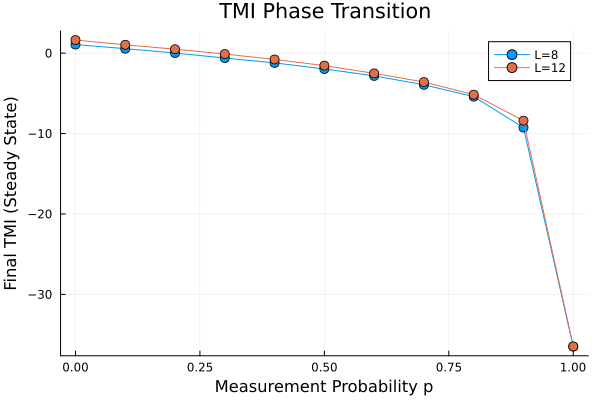

All plots saved.


In [13]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Path to your data
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-tmi-data-Feb3"

L_values = [8, 12]
num_shots = 5000
p_values = range(0.0, 1.0, length=11) # 0.0, 0.1, ... 1.0

# Storage for the final summary plot: Dict(L => (p_vals, final_tmi_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 10.0 * L
    dt = 1.0
    time_steps = Int(T / dt) + 1 # +1 because it includes t=0
    
    # Prepare Plot 1: TMI(t) vs t for this specific L
    plt_time = plot(
        title = "TMI Dynamics (L=$L)",
        xlabel = "Time (t)",
        ylabel = "Tripartite Mutual Info (I3)",
        legend = :outertopright,
        size = (800, 500),
        margin = 5Plots.mm
    )
    
    # Storage for this L to later plot Final TMI vs p
    final_values_for_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.1f", p)
        
        # Accumulator for averaging
        # We assume the time series length is consistent (T/dt + 1)
        accumulated_tmi = zeros(Float64, time_steps)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # Filename format: L8,T80.0,p0.0,s11_tmi.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_tmi.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Ensure trajectory length matches accumulator
                    if length(traj) == length(accumulated_tmi)
                        accumulated_tmi .+= traj
                        count_valid += 1
                    elseif length(traj) > length(accumulated_tmi)
                        # Handle case where file might be slightly longer/shorter
                        len = min(length(traj), length(accumulated_tmi))
                        accumulated_tmi[1:len] .+= traj[1:len]
                        count_valid += 1
                    end
                catch e
                    # Ignore corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_tmi = accumulated_tmi ./ count_valid
            
            # 1. Add to Time Series Plot (Plot lines for subset of p to avoid clutter)
            # Plotting all 11 lines might be messy, but we plot them all as requested
            plot!(plt_time, 0:dt:T, -avg_tmi, label="p=$(p_str)", lw=2, alpha=0.8)
            
            # 2. Extract Final Value (at t=T)
            # We take the mean of the last few steps to smooth out fluctuations if needed, 
            # or just the absolute last point. Here we take the last point.
            push!(final_values_for_L, avg_tmi[end])
            
            print(".") # Progress dot
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(final_values_for_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Save the Time Series plot for this L
    savefig(plt_time, "TMI_TimeEvolution_L$(L).pdf")
    
    # Store data for the final phase transition plot
    summary_data[L] = (collect(p_values), final_values_for_L)
end

# ==========================================
# FINAL SUMMARY PLOT (TMI_final vs p)
# ==========================================

println("\nGenerating Summary Plot (Final TMI vs p)...")

plt_summary = plot(
    title = "TMI Phase Transition",
    xlabel = "Measurement Probability p",
    ylabel = "Final TMI (Steady State)",
    legend = :topright,
    marker = :circle,
    lw = 2
)

# Iterate over sorted L values to keep legend ordered
for L in sort(keys(summary_data) |> collect)
    (p_vals, finals) = summary_data[L]
    plot!(plt_summary, p_vals, log.(-finals), label="L=$L", marker=:circle, markersize=5)
end

display(plt_summary)
savefig(plt_summary, "TMI_PhaseTransition_Summary_log.pdf")
println("All plots saved.")


Processing System Size L = 8 ...
........... Done.

Processing System Size L = 12 ...
........... Done.

Generating Summary Plot (TMI at t=L vs p)...


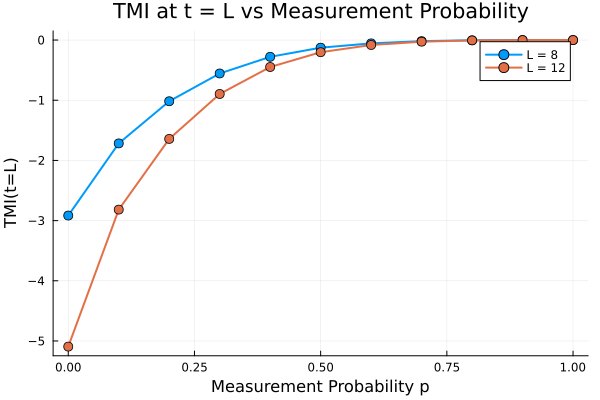

Plot saved as TMI_at_t_equals_L_Summary.png


In [ ]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-tmi-data-Feb3"

L_values = [8, 12]
num_shots = 5000
p_values = range(0.0, 1.0, length=11) # 0.0, 0.1, ... 1.0

# Storage for the summary plot: Dict(L => (p_vals, tmi_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    T = 10.0 * L
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(T / dt) + 1 
    
    # We want to extract the value at time t = L
    # Since array index 1 corresponds to t=0, the index for t=L is L + 1
    target_index = L + 1
    
    # Storage for this specific L
    values_at_t_equals_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.1f", p)
        
        # Accumulator for averaging
        accumulated_tmi = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_tmi.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches if file IO was weird
                    len = min(length(traj), length(accumulated_tmi))
                    accumulated_tmi[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_tmi ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(values_at_t_equals_L, val_at_L)
            else
                println("  Error: Trajectory too short to find t=L for p=$p_str")
                push!(values_at_t_equals_L, NaN)
            end
            
            print(".") 
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(values_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (collect(p_values), values_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (TMI(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (TMI at t=L vs p)...")

plt_summary = plot(
    title = "TMI at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "TMI(t=L)",
    legend = :bottomright,
    grid = true,
    lw = 2
)

# Sort L values so the legend is clean (L=8, then L=12...)
for L in sort(collect(keys(summary_data)))
    (p_vals, tmi_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, tmi_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "TMI_at_t_equals_L_Summary.svg")
println("Plot saved as TMI_at_t_equals_L_Summary.svg")


Processing System Size L = 8 ...
........... Done.

Processing System Size L = 12 ...
........... Done.

Processing System Size L = 16 ...
........... Done.

Generating Summary Plot (Shannon Entropy at t=L vs p)...


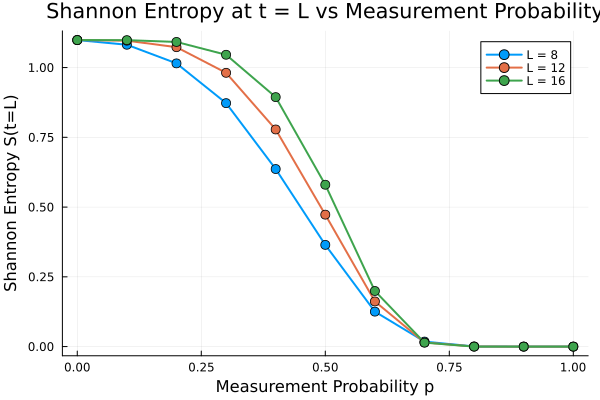

Plot saved as ShannonEntropy_at_t_equals_L_Summary.svg


In [ ]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb4" 

L_values = [8, 12, 16]
num_shots = 5000
p_values = range(0.0, 1.0, length=11) 

# Storage for the summary: Dict(L => (p_vals, se_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # BASED ON YOUR EXAMPLE FILE: "L12,T24.0..."
    # This implies T = 2 * L. 
    # (If your L=8 files used T=80.0, change this back to 10.0 * L)
    T = 2.0 * L  
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(T / dt) + 1 
    
    # We want to extract the value at time t = L
    # Since array index 1 corresponds to t=0, the index for t=L is L + 1
    target_index = L + 1
    
    # Storage for this specific L
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.1f", p)
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # UPDATED FILENAME FORMAT: _se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                println("  Error: Trajectory too short to find t=L for p=$p_str")
                push!(se_at_t_equals_L, NaN)
            end
            
            print(".") 
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Shannon Entropy at t=L vs p)...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary.svg")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary.svg")


Processing System Size L = 8 ...
........... Done.

Processing System Size L = 12 ...
........... Done.

Processing System Size L = 16 ...
........... Done.

Generating Summary Plot (Shannon Entropy at t=L vs p)...


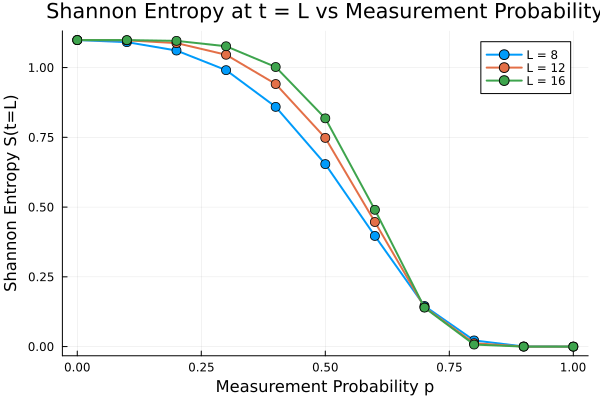

Plot saved as ShannonEntropy_at_t_equals_L_Summary.pdf


In [11]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb4" 

L_values = [8, 12, 16]
num_shots = 5000
p_values = range(0.0, 1.0, length=11) 

# Storage for the summary: Dict(L => (p_vals, se_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # BASED ON YOUR EXAMPLE FILE: "L12,T24.0..."
    # This implies T = 2 * L. 
    # (If your L=8 files used T=80.0, change this back to 10.0 * L)
    T = 2.0 * L  
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(T / dt) + 1 
    
    # We want to extract the value at time t = L
    # Since array index 1 corresponds to t=0, the index for t=L is L + 1
    target_index = L + 1
    
    # Storage for this specific L
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.1f", p)
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # UPDATED FILENAME FORMAT: _se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                println("  Error: Trajectory too short to find t=L for p=$p_str")
                push!(se_at_t_equals_L, NaN)
            end
            
            print(".") 
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Shannon Entropy at t=L vs p)...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary.pdf")


Processing System Size L = 8 ...
...... Done.

Processing System Size L = 12 ...
...... Done.

Processing System Size L = 16 ...
...... Done.

Generating Summary Plot (Shannon Entropy at t=L vs p)...


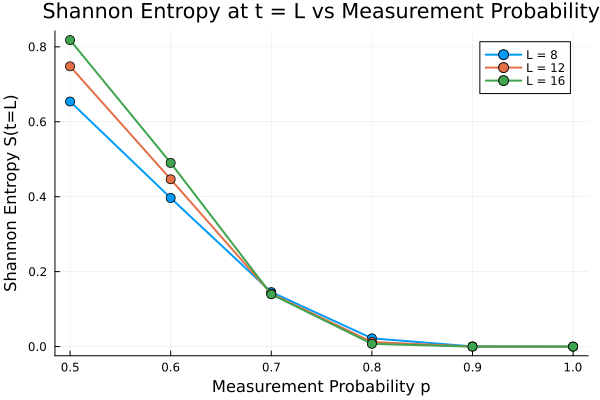

Plot saved as ShannonEntropy_at_t_equals_L_Summary_zoomed.pdf


In [6]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb4" 

L_values = [8, 12, 16]
num_shots = 5000
p_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Storage for the summary: Dict(L => (p_vals, se_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # BASED ON YOUR EXAMPLE FILE: "L12,T24.0..."
    # This implies T = 2 * L. 
    # (If your L=8 files used T=80.0, change this back to 10.0 * L)
    T = 2.0 * L  
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(T / dt) + 1 
    
    # We want to extract the value at time t = L
    # Since array index 1 corresponds to t=0, the index for t=L is L + 1
    target_index = L + 1
    
    # Storage for this specific L
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.1f", p)
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # UPDATED FILENAME FORMAT: _se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                println("  Error: Trajectory too short to find t=L for p=$p_str")
                push!(se_at_t_equals_L, NaN)
            end
            
            print(".") 
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Shannon Entropy at t=L vs p)...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_zoomed.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_zoomed.pdf")

In [ ]:
/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb6


Processing System Size L = 8 ...
.  Warning: No data found for L=8, p=0.550
.  Warning: No data found for L=8, p=0.600
.  Warning: No data found for L=8, p=0.650
.  Warning: No data found for L=8, p=0.700
.  Warning: No data found for L=8, p=0.750
.  Warning: No data found for L=8, p=0.800
.  Warning: No data found for L=8, p=0.850
.  Warning: No data found for L=8, p=0.900
.  Warning: No data found for L=8, p=0.950
.  Warning: No data found for L=8, p=1.000
 Done.

Processing System Size L = 12 ...
.  Warning: No data found for L=12, p=0.550
.  Warning: No data found for L=12, p=0.600
.  Warning: No data found for L=12, p=0.650
.  Warning: No data found for L=12, p=0.700
.  Warning: No data found for L=12, p=0.750
.  Warning: No data found for L=12, p=0.800
.  Warning: No data found for L=12, p=0.850
.  Warning: No data found for L=12, p=0.900
.  Warning: No data found for L=12, p=0.950
.  Warning: No data found for L=12, p=1.000
 Done.

Processing System Size L = 16 ...
.  Warning: 

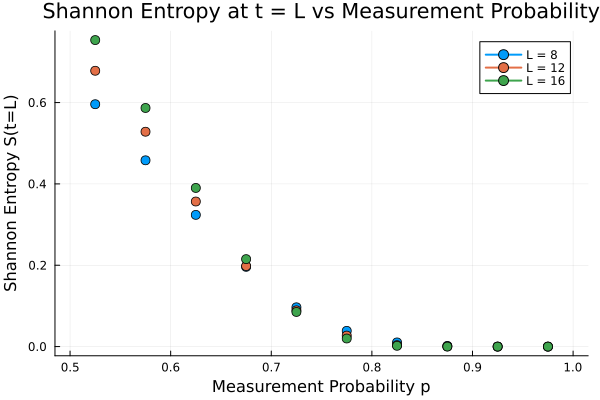

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.pdf


In [9]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
# Update this to the folder where your Shannon Entropy data is stored
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb6" 

L_values = [8, 12, 16]
num_shots = 5000
p_values = range(0.5, 1.0, length=21) 

# Storage for the summary: Dict(L => (p_vals, se_at_L_vals))
summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # BASED ON YOUR EXAMPLE FILE: "L12,T24.0..."
    # This implies T = 2 * L. 
    # (If your L=8 files used T=80.0, change this back to 10.0 * L)
    T = 2.0 * L  
    dt = 1.0
    
    # We expect data for t = 0, 1, ..., T
    expected_length = Int(T / dt) + 1 
    
    # We want to extract the value at time t = L
    # Since array index 1 corresponds to t=0, the index for t=L is L + 1
    target_index = L + 1
    
    # Storage for this specific L
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        p_str = @sprintf("%.3f", p)
        
        # Accumulator for averaging
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        # --- Load 5000 Shots ---
        for s in 1:num_shots
            # UPDATED FILENAME FORMAT: _se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    # Handle slight length mismatches
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch e
                    # Skip corrupted files
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            # --- EXTRACT VALUE AT t = L ---
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                println("  Error: Trajectory too short to find t=L for p=$p_str")
                push!(se_at_t_equals_L, NaN)
            end
            
            print(".") 
        else
            println("  Warning: No data found for L=$L, p=$p_str")
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    
    # Store data for the summary plot
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT (Shannon Entropy(t=L) vs p)
# ==========================================

println("\nGenerating Summary Plot (Shannon Entropy at t=L vs p)...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

# Sort L values so the legend is clean
for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    plot!(plt_summary, p_vals, se_vals, 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.pdf")

In [10]:
range(0.5, 1.0, length=21) 

0.5:0.025:1.0


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


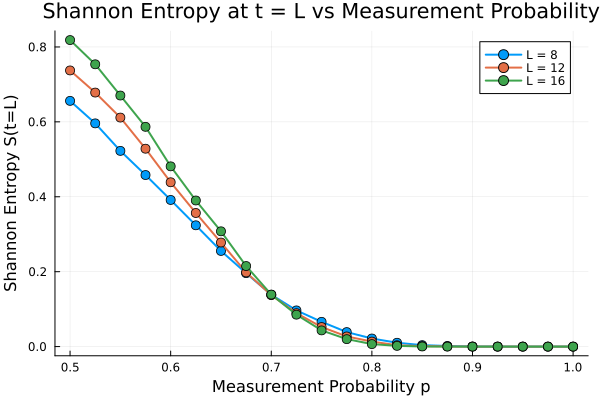

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.pdf


In [11]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb6" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.5, 1.0, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.pdf")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


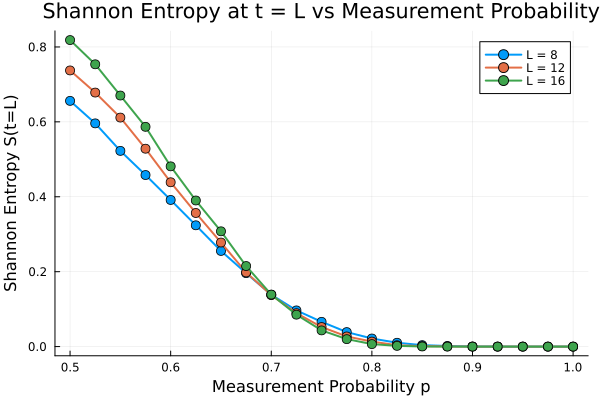

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.svg


In [12]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb6" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.5, 1.0, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#.svg")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.svg")

In [ ]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb6" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.5, 1.0, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=4)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#.svg")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#.svg")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


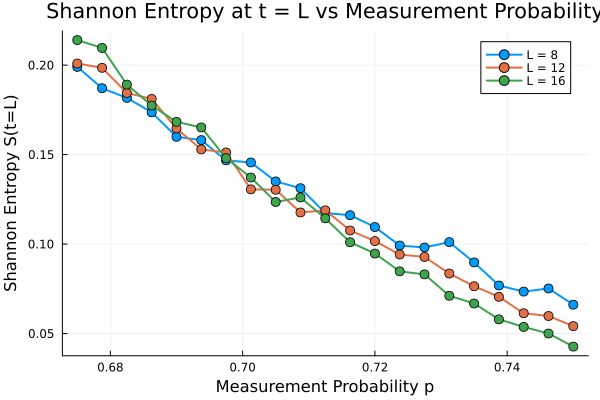

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.pdf


In [14]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb7" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.675, 0.75, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=5)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#c.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.pdf")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

Generating Summary Plot...


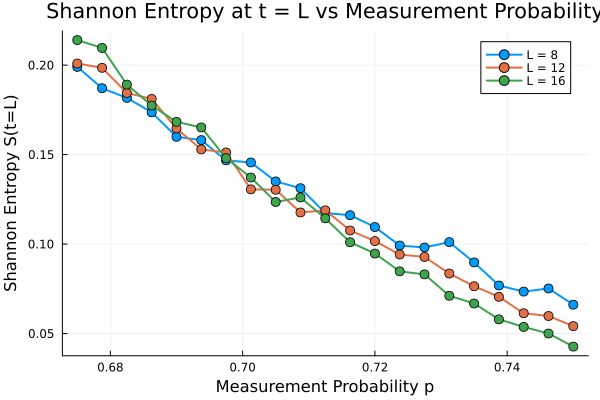

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.pdf


In [15]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb7" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.675, 0.75, length=21) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#c.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.pdf")

In [16]:
using NPZ
using Statistics
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb7" 

# Adjust these to match your actual data scope
L_values = [8, 12, 16]
num_shots = 5000

# p_values as per your previous loop range
p_values = range(0.675, 0.75, length=21) 

# We will store results in a matrix: Rows = L, Cols = p
# Initialize with zeros
results_matrix = zeros(Float64, length(L_values), length(p_values))

# ==========================================
# ANALYSIS LOOP
# ==========================================

# Use enumerate to get the row index 'i' for the matrix
for (i, L) in enumerate(L_values)
    println("\nProcessing System Size L = $L ...")
    
    T = 2.0 * L  
    dt = 1.0
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    # Use enumerate to get the column index 'j' for the matrix
    for (j, p) in enumerate(p_values)
        
        # Clean p string logic
        p_clean = round(p, digits=6)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                results_matrix[i, j] = val_at_L
            else
                results_matrix[i, j] = NaN
            end
            print(".") 
        else
            results_matrix[i, j] = NaN
        end
    end
    println(" Done.")
end

# ==========================================
# OUTPUT GENERATION (Copy-Paste Ready)
# ==========================================

println("\n" * "="^40)
println(" FINAL DATA ARRAYS ")
println("="^40 * "\n")

# Print I matrix (Formatted like Julia array of arrays or Matrix)
println("I = [")
for i in 1:size(results_matrix, 1)
    print("  [")
    for j in 1:size(results_matrix, 2)
        # Check for NaN and print 0.0 or actual value
        val = results_matrix[i, j]
        if isnan(val)
            print("NaN")
        else
            @printf("%.8f", val)
        end
        
        if j < size(results_matrix, 2)
            print(", ")
        end
    end
    if i < size(results_matrix, 1)
        println("],")
    else
        println("]")
    end
end
println("]")

# Print L_vals
print("\nL_vals = [")
for (i, L) in enumerate(L_values)
    print(L)
    if i < length(L_values) print(", ") end
end
println("]")

# Print p_vals
print("\np_vals = [")
for (i, p) in enumerate(p_values)
    @printf("%.4f", p)
    if i < length(p_values) print(", ") end
end
println("]")


Processing System Size L = 8 ...
..................... Done.

Processing System Size L = 12 ...
..................... Done.

Processing System Size L = 16 ...
..................... Done.

 FINAL DATA ARRAYS 

I = [
  [0.19901853, 0.18711005, 0.18168986, 0.17363821, 0.15993803, 0.15809300, 0.14677020, 0.14559929, 0.13501506, 0.13123182, 0.11733033, 0.11614971, 0.10950815, 0.09918227, 0.09809460, 0.10110018, 0.08974273, 0.07685847, 0.07342964, 0.07518079, 0.06612468],
  [0.20092280, 0.19849481, 0.18444237, 0.18109386, 0.16459873, 0.15289455, 0.15120846, 0.13057943, 0.13035791, 0.11767316, 0.11884425, 0.10760185, 0.10167967, 0.09416610, 0.09281016, 0.08353282, 0.07643286, 0.07051061, 0.06134775, 0.05979526, 0.05414692],
  [0.21400571, 0.20960434, 0.18911188, 0.17741516, 0.16828015, 0.16518553, 0.14802796, 0.13720051, 0.12352398, 0.12604909, 0.11437992, 0.10102524, 0.09470870, 0.08475187, 0.08306425, 0.07111180, 0.06678701, 0.05792739, 0.05369276, 0.05001920, 0.04270395]
]

L_vals = [8, 1


Processing System Size L = 8 ...
.. Done.

Processing System Size L = 12 ...
.. Done.

Processing System Size L = 16 ...
.. Done.

Generating Summary Plot...


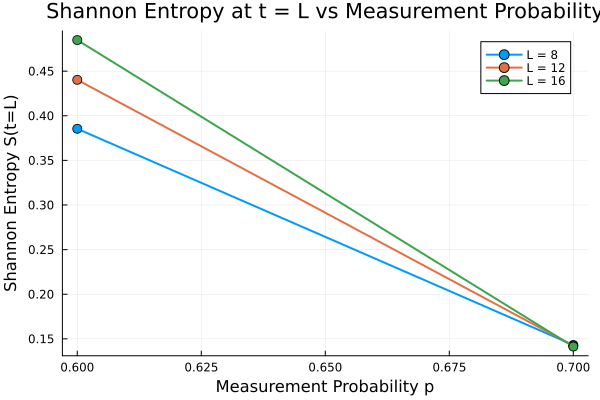

Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.pdf


In [20]:
using NPZ
using Statistics
using Plots
using Printf

# ==========================================
# CONFIGURATION
# ==========================================
data_dir = "/Users/dirac/Projects-Data/z3-data/z3-haar-shannon-data-Feb8" 

L_values = [8, 12, 16]
num_shots = 5000

# This range (0.5 to 1.0 with 21 steps) produces the step size 0.025
# Values: 0.5, 0.525, 0.55 ... 0.75 ... 1.0
p_values = range(0.6, 0.7, length=20) 

summary_data = Dict{Int, Tuple{Vector{Float64}, Vector{Float64}}}()

# ==========================================
# ANALYSIS LOOP
# ==========================================

for L in L_values
    println("\nProcessing System Size L = $L ...")
    
    # Filenames conform to T = 2.0 * L (e.g., L8->T16.0, L12->T24.0)
    T = 2.0 * L  
    dt = 1.0
    
    expected_length = Int(T / dt) + 1 
    target_index = L + 1
    
    se_at_t_equals_L = Float64[]
    
    for p in p_values
        # 1. Round to avoid machine epsilon errors (e.g. 0.6000000001)
        # 2. Convert to string to handle variable length (0.8 vs 0.625)
        #    string(0.8) -> "0.8"
        #    string(0.625) -> "0.625"
        #    string(1.0) -> "1.0"
        p_clean = round(p, digits=16)
        p_str = string(p_clean)
        
        accumulated_se = zeros(Float64, expected_length)
        count_valid = 0
        
        for s in 1:num_shots
            # Filename format: L12,T24.0,p0.8,s1554_se.npy
            fname = "L$(L),T$(T),p$(p_str),s$(s)_se.npy"
            fpath = joinpath(data_dir, fname)
            
            if isfile(fpath)
                try
                    traj = npzread(fpath)
                    
                    len = min(length(traj), length(accumulated_se))
                    accumulated_se[1:len] .+= traj[1:len]
                    count_valid += 1
                catch
                    # Skip corrupted
                end
            end
        end
        
        if count_valid > 0
            avg_traj = accumulated_se ./ count_valid
            
            if length(avg_traj) >= target_index
                val_at_L = avg_traj[target_index]
                push!(se_at_t_equals_L, val_at_L)
            else
                push!(se_at_t_equals_L, NaN)
            end
            print(".") 
        else
            # print("x") # Optional: mark missing data
            push!(se_at_t_equals_L, NaN)
        end
    end
    
    println(" Done.")
    summary_data[L] = (collect(p_values), se_at_t_equals_L)
end

# ==========================================
# SUMMARY PLOT
# ==========================================

println("\nGenerating Summary Plot...")

plt_summary = plot(
    title = "Shannon Entropy at t = L vs Measurement Probability",
    xlabel = "Measurement Probability p",
    ylabel = "Shannon Entropy S(t=L)",
    legend = :topright,
    grid = true,
    lw = 2
)

for L in sort(collect(keys(summary_data)))
    (p_vals, se_vals) = summary_data[L]
    
    # Filter out NaNs for cleaner plotting lines
    mask = .!isnan.(se_vals)
    
    plot!(plt_summary, p_vals[mask], se_vals[mask], 
        label = "L = $L", 
        marker = :circle, 
        markersize = 5,
        lw = 2
    )
end

display(plt_summary)
savefig(plt_summary, "ShannonEntropy_at_t_equals_L_Summary_p#c.pdf")
println("Plot saved as ShannonEntropy_at_t_equals_L_Summary_p#c.pdf")